# Retrieval Evaluation (synthetic test set)

[Hugging Face RAG Evaluation cookbook](https://huggingface.co/learn/cookbook/en/rag_evaluation):

In [64]:
import sys, os, re, json, time, math, hashlib, random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# make src/ importable and load the API key  
ROOT = Path.cwd().parent                   
sys.path.insert(0, str(ROOT / 'src'))

from dotenv import load_dotenv
load_dotenv(ROOT / 'data' / '.env', override=True)  
assert os.getenv('OPENAI_API_KEY'), 'OPENAI_API_KEY not loaded - check the .env path above'
print('key loaded, src on path | ROOT =', ROOT)

key loaded, src on path | ROOT = /Users/afrahalharbi/Desktop/Imperial/Project/code/code/SAIT


In [65]:
# Build the retrival
from config import Config
from retrieval import KnowledgeBase

config = Config.load()
kb = KnowledgeBase(config).build()
retriever = kb.as_retriever()

CONFIG_K = getattr(getattr(config, 'retriever', None), 'k', None)
if CONFIG_K is None:   # fall back to the k the retriever actually uses
    CONFIG_K = (getattr(retriever, 'search_kwargs', {}) or {}).get('k')
assert CONFIG_K, 'could not determine k - set CONFIG_K by hand'
print('retriever ready | config k =', CONFIG_K)
print('retriever type   =', type(retriever).__name__)
print('search_type      =', getattr(retriever, 'search_type', '(n/a)'))
print('search_kwargs    =', getattr(retriever, 'search_kwargs', '(n/a)'))

Loading existing ChromaDB vector store...
retriever ready | config k = 5
retriever type   = VectorStoreRetriever
search_type      = similarity
search_kwargs    = {'k': 5}


## 1. Build synthetic evaluation set to evlaute the RAG

We sample chunks from the same knowledge base the retriever indexes, then generate  a pair of question/answer for each. Because we know which chunk each question came from, we record its id, page and text as ground truth.

In [66]:
from openai import OpenAI
from tqdm.auto import tqdm

# reads openai key
client = OpenAI()

# generator and critique model
GEN_MODEL = 'gpt-4o-mini'       
# chunks to sample, the number of questions
N_SAMPLE = 200 
# skip chunks with less than 80 characters              
MIN_CHUNK_CHARS = 80                 
# keep questions scoring >= threshold on every critique
SCORE_THRESHOLD = 4      
MAX_WORKERS = 8 
# number of attempts for calling                
MAX_RETRIES = 4                   
PARAPHRASE = False   

JSON_SYSTEM = 'You are a helpful assistant. Reply with a single JSON object and nothing else.'

def chat_json(prompt, system=JSON_SYSTEM, model=GEN_MODEL):
    last_err = None
    for attempt in range(MAX_RETRIES):
        try:
            resp = client.chat.completions.create(
                model=model,
                temperature=0,
                response_format={'type': 'json_object'},
                messages=[{'role': 'system', 'content': system},
                          {'role': 'user',   'content': prompt}],
            )
            return json.loads(resp.choices[0].message.content)
        except Exception as e:
            last_err = e
            if attempt < MAX_RETRIES - 1:
                time.sleep(2 ** attempt + random.random())
    raise last_err

def run_parallel(fn, items, desc, workers=MAX_WORKERS):
    results, errors = [None] * len(items), []
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = {ex.submit(fn, it): i for i, it in enumerate(items)}
        for fut in tqdm(as_completed(futures), total=len(futures), desc=desc):
            i = futures[fut]
            try:
                results[i] = fut.result()
            except Exception as e:
                errors.append((i, repr(e)))
    return results, errors

print('OpenAI client ready: ', GEN_MODEL, ' workers =', MAX_WORKERS)

OpenAI client ready:  gpt-4o-mini  workers = 8


In [67]:
# get all the chunks the retiever uses

def normalize(text: str) -> str:
    # collapse whitespace + lowercase so small formatting differences don't matter
    return re.sub(r'\s+', ' ', (text or '')).strip().lower()

def chunk_id(text: str) -> str:
    # hash of the normalized text, used as the chunk's ID
    return hashlib.sha1(normalize(text).encode('utf-8')).hexdigest()[:16]

def page_key(p):
    # some stores save page as int, some as str, make them comparable
    if p is None:
        return None
    try:
        return int(p)
    except (TypeError, ValueError):
        return str(p).strip()

def basename(src):
    return os.path.basename(src) if src else '?'

def collect_chunks(kb):
    vs = getattr(kb, 'vectorstore', None)

    if vs is not None and hasattr(vs, 'get'):
        try:
            from langchain_core.documents import Document
            raw = vs.get(include=['documents', 'metadatas'])
            return [Document(page_content=t, metadata=m or {})
                    for t, m in zip(raw['documents'], raw['metadatas'])]
        except Exception as e:
            print('chroma .get() failed, falling through:', repr(e))

    # fallback, might be the kb has the chunks
    for attr in ('chunks', 'documents', 'docs'):
        if hasattr(kb, attr):
            return list(getattr(kb, attr))

    raise RuntimeError(
        'Could not locate source chunks. Point collect_chunks() at wherever your '
        'KnowledgeBase keeps its split documents.'
    )

all_chunks = collect_chunks(kb)

# check page metadata types before comparison 
page_types = {type(c.metadata.get('page')).__name__ for c in all_chunks}
print(f'{len(all_chunks)} chunks total, page metadata types: {sorted(page_types)}')
n_no_page = sum(1 for c in all_chunks if c.metadata.get('page') is None)
if n_no_page:
    print(f'  warning: {n_no_page} chunks have no page metadata '
          f'-> page-based metrics will exclude questions drawn from them')

# skip duplicat chuncks
from collections import Counter
id_counts = Counter(chunk_id(c.page_content) for c in all_chunks)
n_dupes = sum(1 for cid, n in id_counts.items() if n > 1)
if n_dupes:
    print(f'  note: {n_dupes} chunk texts appear more than once; excluded from sampling')

usable = [c for c in all_chunks
          if len((c.page_content or '').strip()) >= MIN_CHUNK_CHARS
          and id_counts[chunk_id(c.page_content)] == 1]
print(f'{len(usable)} usable (>= {MIN_CHUNK_CHARS} chars, unique text)')
assert usable, 'no usable chunks - lower MIN_CHUNK_CHARS or check the knowledge base'

random.seed(0)
sampled = random.sample(usable, min(N_SAMPLE, len(usable)))

lengths = sorted(len(c.page_content) for c in sampled)
print(f'sampled {len(sampled)} chunks, chunk chars: '
      f'min={lengths[0]} median={lengths[len(lengths)//2]} max={lengths[-1]}')

115 chunks total, page metadata types: ['int']
  note: 1 chunk texts appear more than once; excluded from sampling
106 usable (>= 80 chars, unique text)
sampled 106 chunks, chunk chars: min=239 median=933 max=998


In [68]:
# generate a synthitic question/answer per chucnk
QA_GEN_PROMPT = """Your task is to write a question and an answer given a context.
Your question should be answerable with a specific, concise piece of factual
information from the context. Formulate it in the style a user would type into a search
engine. The question should not mention "the context", "the passage", "the document",
or refer to the source in any way.

Return a JSON object with exactly these keys:
  "question": the question
  "answer": a concise answer (a few words to one sentence)

Context:
{context}"""

def gen_one(chunk):
    out = chat_json(QA_GEN_PROMPT.format(context=chunk.page_content))
    question = str(out.get('question', '')).strip()
    answer   = str(out.get('answer', '')).strip()
    if not question or not answer or len(answer) > 300:
        raise ValueError(f'unusable generation: q={question[:40]!r} a_len={len(answer)}')
    return {
        'query':   question,
        'answer':  answer,
        'expected_chunk_id': chunk_id(chunk.page_content),
        'expected_page': page_key(chunk.metadata.get('page')),
        'source': basename(chunk.metadata.get('source')),
        'source_excerpt': chunk.page_content,
    }

gen_results, gen_errors = run_parallel(gen_one, sampled, 'generating QA')
raw_items = [r for r in gen_results if r is not None]

print(f'{len(raw_items)} raw QA couples generated of {len(sampled)} sampled '
      f'| {len(gen_errors)} failed')
for i, err in gen_errors[:5]:
    print('   ', err[:140])
if len(gen_errors) > 5:
    print(f'    ... and {len(gen_errors) - 5} more')
assert raw_items, 'no questions generated - check the API errors above'

generating QA: 100%|██████████| 106/106 [00:16<00:00,  6.47it/s]

106 raw QA couples generated of 106 sampled | 0 failed


Delet this cell

In [12]:
# --- OPTIONAL: paraphrase into a student's register ---
# Questions written FROM a chunk inherit that chunk's vocabulary, so the retriever gets
# an unrealistically strong lexical signal and Hit@k reads optimistically. Paraphrasing
# closes part of that gap. Set PARAPHRASE = True above to enable; run both and report
# the pair - the difference IS the leakage estimate.

PARAPHRASE_PROMPT = """Rewrite this question the way a student would actually type it when
searching course material. Keep the exact same information need and keep it answerable by
the same fact, but avoid copying distinctive wording where a natural synonym exists.
Do not make it vaguer and do not add new constraints.

Return JSON with a single key "question".

Question: {question}"""

if PARAPHRASE:
    def para_one(item):
        out = chat_json(PARAPHRASE_PROMPT.format(question=item['query']))
        q = str(out.get('question', '')).strip()
        if not q:
            raise ValueError('empty paraphrase')
        return q

    paras, para_errors = run_parallel(para_one, raw_items, 'paraphrasing')
    n_changed = 0
    for item, q in zip(raw_items, paras):
        if q:
            item['original_query'] = item['query']
            item['query'] = q
            n_changed += 1
    print(f'paraphrased {n_changed}/{len(raw_items)} | {len(para_errors)} failed '
          '(originals kept where paraphrasing failed)')
else:
    print('paraphrase disabled (PARAPHRASE = False) - expect optimistic Hit@k')

paraphrase disabled (PARAPHRASE = False) - expect optimistic Hit@k


In [69]:
# critique step: score each question and filter out the weak ones
GROUNDEDNESS_PROMPT = """Given a context and a question, rate how well the question can be
answered unambiguously using only that context, from 1 (not answerable) to 5 (clearly
and unambiguously answerable).

Return JSON with keys "evaluation" (short rationale) and "rating" (integer 1-5).

Question: {question}
Context: {context}"""

RELEVANCE_PROMPT = """Rate how useful this question is to a student studying this course
material with the tutor, from 1 (useless) to 5 (very useful).

Return JSON with keys "evaluation" (short rationale) and "rating" (integer 1-5).

Question: {question}"""

STANDALONE_PROMPT = """Rate how context-independent this question is, from 1 to 5.
5 = makes sense on its own to someone with domain knowledge and access to documentation.
1 = depends on unstated context (e.g. it says "in the document", "in this guide",
"the function used here"). Technical nouns/acronyms are fine and can still score 5.

Return JSON with keys "evaluation" (short rationale) and "rating" (integer 1-5).

Question: {question}"""

def parse_rating(value):
    if isinstance(value, bool):
        raise ValueError(f'bool rating: {value!r}')
    if isinstance(value, (int, float)):
        rating = int(value)
    else:
        m = re.search(r'\d+', str(value))
        if not m:
            raise ValueError(f'no number in rating {value!r}')
        rating = int(m.group())
    if not 1 <= rating <= 5:
        raise ValueError(f'rating out of range: {rating}')
    return rating

def critique_one(item):
    prompts = {
        'groundedness': GROUNDEDNESS_PROMPT.format(question=item['query'], context=item['source_excerpt']),
        'relevance': RELEVANCE_PROMPT.format(question=item['query']),
        'standalone': STANDALONE_PROMPT.format(question=item['query']),
    }
    scored = {}
    for name, prompt in prompts.items():
        out = chat_json(prompt)
        scored[f'{name}_score'] = parse_rating(out['rating'])
        scored[f'{name}_eval']  = str(out.get('evaluation', ''))
    return scored

crit_results, crit_errors = run_parallel(critique_one, raw_items, 'critiquing')
for item, scored in zip(raw_items, crit_results):
    if scored is None:
        item['critique_failed'] = True        
    else:
        item.update(scored)
        item['critique_failed'] = False

print(f'critique done: {len(crit_errors)} items failed to score (API/parse errors)')
for i, err in crit_errors[:5]:
    print('   ', err[:140])

critiquing:   0%|          | 0/106 [00:00<?, ?it/s]

critiquing: 100%|██████████| 106/106 [00:50<00:00,  2.12it/s]

critique done: 0 items failed to score (API/parse errors)


In [70]:
# filtering step: filter the final questions
def passes(item):
    if item.get('critique_failed'):
        return False
    return all(item.get(f'{k}_score', 0) >= SCORE_THRESHOLD
               for k in ('groundedness', 'relevance', 'standalone'))

testset = [
    {'query': it['query'],
     'answer': it['answer'],
     'expected_chunk_id': it['expected_chunk_id'],
     'expected_page': it['expected_page'],
     'source': it['source'],
     'source_excerpt': it['source_excerpt']}
    for it in raw_items if passes(it)
]

# count low scores and error seperately
n_failed  = sum(1 for it in raw_items if it.get('critique_failed'))
n_lowqual = len(raw_items) - len(testset) - n_failed
print(f'{len(sampled)} sampled -> {len(raw_items)} generated -> {len(testset)} kept')
print(f'  dropped: {n_lowqual} below threshold {SCORE_THRESHOLD}, '
      f'{n_failed} unscored (errors), {len(gen_errors)} failed generation')
assert testset, 'empty test set - loosen SCORE_THRESHOLD or investigate the errors above'

for key in ('groundedness', 'relevance', 'standalone'):
    vals = [it[f'{key}_score'] for it in raw_items if not it.get('critique_failed')]
    if vals:
        print(f'  {key:>13} mean = {sum(vals)/len(vals):.2f} '
              f', >= {SCORE_THRESHOLD}: {sum(1 for v in vals if v >= SCORE_THRESHOLD)}/{len(vals)}')

TESTSET_PATH = ROOT / 'data' / 'retrieval_testset.json'
TESTSET_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(TESTSET_PATH, 'w', encoding='utf-8') as f:
    json.dump(testset, f, ensure_ascii=False, indent=2)
print('saved ->', TESTSET_PATH)

for t in testset[:2]:
    print('\nQ :', t['query'])
    print('pg:', t['expected_page'], ', id:', t['expected_chunk_id'],
          '| excerpt:', t['source_excerpt'][:-1], '...')

106 sampled -> 106 generated -> 79 kept
  dropped: 27 below threshold 4, 0 unscored (errors), 0 failed generation
   groundedness mean = 4.77 , >= 4: 98/106
      relevance mean = 4.71 , >= 4: 103/106
     standalone mean = 4.34 , >= 4: 83/106
saved -> /Users/afrahalharbi/Desktop/Imperial/Project/code/code/SAIT/data/retrieval_testset.json

Q : What is a simple graph?
pg: 0 , id: b4f2bbdb1c81c663 | excerpt: 0 1 
2 3 
G2 
0 
1 2 
G3 
a 
b 
s 
c 
d 
e 
f 
g 
• Graph G =( V, E) is a set of vertices V and a set of pairs of vertices E ⊆ V × V . 
• Directed edges are ordered pairs, e.g., (u, v) for u, v ∈ V 
• Undirected edges are unordered pairs, e.g., {u, v} for u, v ∈ V i.e., (u, v) and (v, u) 
• In this class, we assume all graphs are simple: 
– edges are distinct, e.g., (u, v) only occurs once in E (though (v, u) may appear), and 
– edges are pairs of distinct vertices, e.g., u =6 v for all (u, v) ∈ E 
�  � |V | |V |– Simple implies |E| = O(|V |2), since |E|≤ for undirected, ≤ 2 for di

## 2. Score retrieval on the synthetic set

Consumes the `testset` list built above. To re-score a saved set without re-generating,
skip section 1 and run:

```python
testset = json.load(open(ROOT / 'data' / 'retrieval_testset.json', encoding='utf-8'))
```

(You still need the cells that define `retriever`, `normalize`, `chunk_id` and `page_key`.)

In [71]:
# scoring helpers
def prefix_overlap(chunk_text: str, excerpt: str, window: int = 40) -> bool:
    """DIAGNOSTIC ONLY. True if the excerpt's leading slice appears in the chunk.
    This is what the old strict metric did, and it over-counts: text splitters use a
    chunk_overlap, so the first characters of chunk N also sit at the tail of chunk N-1.
    Kept solely to measure that over-count against the exact chunk_id match."""
    c, e = normalize(chunk_text), normalize(excerpt)
    probe = e[:window]
    return bool(probe) and probe in c

def evaluate_item(item, r=None):
    """Retrieve for one query; return per-item rank info."""
    r = r or retriever
    docs = r.invoke(item['query'])
    exp_page = page_key(item.get('expected_page'))
    exp_id   = item['expected_chunk_id']
    excerpt  = item.get('source_excerpt', '')

    chunk_rank = page_rank = prefix_rank = None
    for i, d in enumerate(docs, start=1):
        if chunk_rank is None and chunk_id(d.page_content) == exp_id:
            chunk_rank = i
        # exp_page None means "no ground-truth page" - never treat that as a match,
        # or every chunk that also lacks page metadata scores a spurious rank-1 hit.
        if (page_rank is None and exp_page is not None
                and basename(d.metadata.get('source')) == item.get('source')
                and page_key(d.metadata.get('page')) == exp_page):
            page_rank = i
        if prefix_rank is None and prefix_overlap(d.page_content, excerpt):
            prefix_rank = i

    return {
        'query': item['query'],
        'expected_page': exp_page,
        'has_page_label': exp_page is not None,
        'chunk_rank': chunk_rank,
        'page_rank': page_rank,
        'prefix_rank': prefix_rank,
        'n_docs': len(docs),
        'retrieved_pages': [page_key(d.metadata.get('page')) for d in docs],
        'retrieved_sources': [basename(d.metadata.get('source')) for d in docs],
    }

In [ ]:
# --- run the evaluation over all items ---
results = [evaluate_item(it) for it in tqdm(testset, desc='retrieving')]

n = len(results)
assert n, 'no results to score'

def hit_rate(key, subset=None):
    rows = subset if subset is not None else results
    if not rows:
        return None, 0, 0
    hits = sum(1 for r in rows if r[key] is not None)
    return hits / len(rows), hits, len(rows)

def mrr(key, subset=None):
    rows = subset if subset is not None else results
    if not rows:
        return None
    return sum(1.0 / r[key] for r in rows if r[key]) / len(rows)   # misses contribute 0

paged = [r for r in results if r['has_page_label']]

print(f'Test items: {n}   (k = {CONFIG_K}, observed n_docs = '
      f'{sorted({r["n_docs"] for r in results})})')
print('-' * 52)
rate, hits, tot = hit_rate('chunk_rank')
print(f'Hit@k (chunk)   : {hits}/{tot} = {rate:.1%}      <- headline')
if paged:
    rate, hits, tot = hit_rate('page_rank', paged)
    print(f'Hit@k (page)    : {hits}/{tot} = {rate:.1%}      '
          f'({n - len(paged)} items excluded: no page label)')
else:
    print('Hit@k (page)    : n/a - no items carry page metadata')
rate, hits, tot = hit_rate('prefix_rank')
print(f'Hit@k (prefix)  : {hits}/{tot} = {rate:.1%}      (diagnostic, over-counts)')
print(f'MRR (chunk)     : {mrr("chunk_rank"):.3f}')
if paged:
    print(f'MRR (page)      : {mrr("page_rank", paged):.3f}')
    print(f'Random baseline : Hit@k (chunk) = {CONFIG_K}/{len(all_chunks)} = {CONFIG_K/len(all_chunks):.1%}')
# How much would prefix matching have inflated the strict number?
inflated = [r for r in results if r['prefix_rank'] is not None and r['chunk_rank'] is None]
print('-' * 52)
print(f'Prefix-only hits (would have been false positives): {len(inflated)}/{n}')
if paged:
    page_only = [r for r in paged if r['page_rank'] is not None and r['chunk_rank'] is None]
    print(f'Page-only hits   (right page, wrong chunk)        : {len(page_only)}/{len(paged)}')

retrieving: 100%|██████████| 79/79 [00:18<00:00,  4.36it/s]

Test items: 79   (k = 5, observed n_docs = [5])
----------------------------------------------------
Hit@k (chunk)   : 68/79 = 86.1%      <- headline
Hit@k (page)    : 78/79 = 98.7%      (0 items excluded: no page label)
Hit@k (prefix)  : 72/79 = 91.1%      (diagnostic, over-counts)
MRR (chunk)     : 0.693
MRR (page)      : 0.845
----------------------------------------------------
Prefix-only hits (would have been false positives): 4/79
Page-only hits   (right page, wrong chunk)        : 10/79


In [72]:
# --- inspect the FAILURES so you can see WHY it missed ---
misses = [(it, r) for it, r in zip(testset, results) if r['chunk_rank'] is None]
print(f'{len(misses)} chunk-misses out of {n}\n')
for it, r in misses:
    print('Q:', r['query'][:90], '...')
    print('   expected      :', it['source'], '| page', it['expected_page'],
          '| id', it['expected_chunk_id'][:8])
    print('   retrieved     :', list(zip(r['retrieved_sources'], r['retrieved_pages'])))
    if r['prefix_rank']:
        print('   note          : prefix-matched a neighbouring chunk '
              '(answer may straddle a chunk boundary)')
    print()

11 chunk-misses out of 79

Q: What is the time complexity of the algorithm described? ...
   expected      : 77ff36ad54779575d9ba8d8687f91b5b_MIT6_006S20_r11.pdf | page 4 | id 4efd3f10
   retrieved     : [('d819e7f4568aced8d5b59e03db6c7b67_MIT6_006S20_lec13.pdf', 3), ('6d1ae5278d02bbecb5c4428928b24194_MIT6_006S20_lec3.pdf', 4), ('6d1ae5278d02bbecb5c4428928b24194_MIT6_006S20_lec3.pdf', 2), ('77ff36ad54779575d9ba8d8687f91b5b_MIT6_006S20_r11.pdf', 2), ('ec187276db0faaa047d655979a44de7f_MIT6_006S20_r13.pdf', 2)]

Q: What is the time complexity of the algorithm for solving the Single Source Shortest Path ( ...
   expected      : 6afd7e9a85d7d36e204533569f9fccf6_MIT6_006S20_r09.pdf | page 2 | id 595f5323
   retrieved     : [('77ff36ad54779575d9ba8d8687f91b5b_MIT6_006S20_r11.pdf', 1), ('aa57a9785adf925bc85c1920f53755a0_MIT6_006S20_lec11.pdf', 1), ('d819e7f4568aced8d5b59e03db6c7b67_MIT6_006S20_lec13.pdf', 0), ('aa57a9785adf925bc85c1920f53755a0_MIT6_006S20_lec11.pdf', 1), ('d819e7f4568aced8d5b5

In [73]:
# --- sweep k, using the SAME retriever configuration as the headline numbers ---
# Building a bare vectorstore retriever here would silently drop MMR / score thresholds /
# any config-driven search settings, so the sweep would measure a different system than
# the one scored above. We clone the live retriever's settings and override only k.

def build_retriever(k):
    vs = getattr(kb, 'vectorstore', None) or getattr(retriever, 'vectorstore', None)
    if vs is None:
        raise RuntimeError('no vectorstore found on kb or retriever - '
                           'point build_retriever() at your own construction path')
    search_type   = getattr(retriever, 'search_type', 'similarity')
    search_kwargs = dict(getattr(retriever, 'search_kwargs', {}) or {})
    search_kwargs['k'] = k
    if search_type == 'mmr':                       # keep the candidate pool ahead of k
        search_kwargs['fetch_k'] = max(search_kwargs.get('fetch_k', 20), 4 * k)
    return vs.as_retriever(search_type=search_type, search_kwargs=search_kwargs)

if not hasattr(retriever, 'search_kwargs'):
    print('WARNING: the live retriever exposes no search_kwargs (it may wrap a compressor,\n'
          '         reranker or ensemble). The sweep below reconstructs only the vector\n'
          '         search stage, so treat its numbers as a lower bound.\n')

sweep_ks = [3, 5, 8, 10, 15, 20]
sweep, sweep_rows = {}, {}
for k in sweep_ks:
    r_k = build_retriever(k)
    rows = [evaluate_item(it, r=r_k) for it in testset]
    hits = sum(1 for r in rows if r['chunk_rank'] is not None)
    sweep[k], sweep_rows[k] = hits, rows
    print(f'k={k:>2}:  chunk Hit@k = {hits}/{n} = {hits/n:.1%}   MRR = {mrr("chunk_rank", rows):.3f}')

# Consistency check: at the configured k the sweep must reproduce the headline number.
if CONFIG_K in sweep:
    headline = sum(1 for r in results if r['chunk_rank'] is not None)
    if sweep[CONFIG_K] != headline:
        print(f'\nWARNING: sweep at k={CONFIG_K} gives {sweep[CONFIG_K]} hits but the headline '
              f'eval gives {headline}.\n         build_retriever() is not reproducing '
              'kb.as_retriever() - fix that before trusting the sweep.')
    else:
        print(f'\nconsistency check passed: sweep at k={CONFIG_K} matches the headline eval')
else:
    print(f'\nnote: configured k={CONFIG_K} is not in the sweep, so no consistency check ran')

k= 3:  chunk Hit@k = 59/79 = 74.7%   MRR = 0.627
k= 5:  chunk Hit@k = 67/79 = 84.8%   MRR = 0.650
k= 8:  chunk Hit@k = 70/79 = 88.6%   MRR = 0.656
k=10:  chunk Hit@k = 72/79 = 91.1%   MRR = 0.659
k=15:  chunk Hit@k = 76/79 = 96.2%   MRR = 0.662
k=20:  chunk Hit@k = 77/79 = 97.5%   MRR = 0.663

         build_retriever() is not reproducing kb.as_retriever() - fix that before trusting the sweep.


## 3. Is the harness itself working?

A broken evaluator produces a plausible-looking Hit@k just as easily as a working one, so
these checks test the *instrument*, not the retriever. Run them once when you set the
notebook up, and again any time you change chunking, the embedding model or the store.

Each cell prints an expected range. A result outside it means the harness is wrong and the
metrics above are meaningless - fix it before reading anything into them.

In [74]:
# --- CHECK 1: wiring. Do collected chunks and retrieved documents live in the same index?
# If collect_chunks() reads a different corpus than the retriever queries (stale index,
# rebuilt store, different splitter settings), every item misses and you conclude
# "retrieval is terrible" when actually nothing was ever comparable.
kb_ids = {chunk_id(c.page_content) for c in all_chunks}

probe_docs = []
for it in testset[:5]:
    probe_docs.extend(retriever.invoke(it['query']))
ret_ids = {chunk_id(d.page_content) for d in probe_docs}
overlap = len(ret_ids & kb_ids)

print(f'retrieved ids found in collected chunks: {overlap}/{len(ret_ids)}')
print('EXPECT: all of them. 0 means collect_chunks() and the retriever disagree about')
print('        the corpus - nothing below this line is interpretable until that is fixed.')
assert overlap > 0, 'collected chunks and retrieved documents share no ids'
if overlap < len(ret_ids):
    print(f'WARNING: {len(ret_ids) - overlap} retrieved chunks are not in the collected set -'
          ' the index and collect_chunks() have partly diverged (stale index?)')

retrieved ids found in collected chunks: 22/22
EXPECT: all of them. 0 means collect_chunks() and the retriever disagree about
        the corpus - nothing below this line is interpretable until that is fixed.


In [75]:
# --- CHECK 2: ceiling. Feed the chunk text back in as the query.
# This is the easiest possible retrieval task, so it isolates plumbing from model quality:
# a low score here is a bug (id mismatch, normalization drift, retriever returning nothing),
# not a weak embedding model.
probe = random.Random(1).sample(testset, min(20, len(testset)))
oracle_hits, oracle_rank1 = 0, 0
for it in probe:
    docs = retriever.invoke(it['source_excerpt'][:500])   # truncated: encoders have limits
    ids = [chunk_id(d.page_content) for d in docs]
    if it['expected_chunk_id'] in ids:
        oracle_hits += 1
        if ids[0] == it['expected_chunk_id']:
            oracle_rank1 += 1

print(f'oracle Hit@k    : {oracle_hits}/{len(probe)}')
print(f'oracle rank-1   : {oracle_rank1}/{len(probe)}')
print('EXPECT: Hit@k at or very near 100%, rank-1 close behind.')
print('        Below ~90% means the harness is broken, not the retriever.')

oracle Hit@k    : 20/20
oracle rank-1   : 20/20
EXPECT: Hit@k at or very near 100%, rank-1 close behind.
        Below ~90% means the harness is broken, not the retriever.


In [76]:
# --- CHECK 3: floor. Pair each question with someone ELSE's chunk as ground truth.
# The score should collapse. If it does not, the matching is too loose - duplicated
# boilerplate in the index, or an identity function that is not actually discriminating.
shuffled = [
    {**it,
     'expected_chunk_id': other['expected_chunk_id'],
     'expected_page':     other['expected_page'],
     'source':            other['source'],
     'source_excerpt':    other['source_excerpt']}
    for it, other in zip(testset, testset[1:] + testset[:1])
]
null_rows = [evaluate_item(it) for it in tqdm(shuffled, desc='negative control')]
null_chunk = sum(1 for r in null_rows if r['chunk_rank'] is not None)
null_page  = sum(1 for r in null_rows if r['has_page_label'] and r['page_rank'] is not None)

print(f'shuffled-label Hit@k (chunk): {null_chunk}/{len(shuffled)} = {null_chunk/len(shuffled):.1%}')
print(f'shuffled-label Hit@k (page) : {null_page}/{len(shuffled)}')
print(f'EXPECT: chunk near chance (k/{len(all_chunks)} = {CONFIG_K/len(all_chunks):.1%}). Page a little higher,')
print('        since several chunks share a page - that is the floor the real page number must beat.')

negative control: 100%|██████████| 79/79 [00:13<00:00,  5.93it/s]

shuffled-label Hit@k (chunk): 2/79 = 2.5%
shuffled-label Hit@k (page) : 8/79
EXPECT: chunk near chance (k/115 = 4.3%). Page a little higher,
        since several chunks share a page - that is the floor the real page number must beat.


In [77]:
# --- CHECK 4: are the critique agents actually filtering anything?
from collections import Counter
for key in ('groundedness', 'relevance', 'standalone'):
    dist = Counter(it.get(f'{key}_score') for it in raw_items if not it.get('critique_failed'))
    total = sum(dist.values())
    top = dist.get(5, 0) / total if total else 0
    flag = '  <- not discriminating' if top > 0.9 else ''
    print(f'{key:>13}: ' + ' '.join(f'{s}:{dist.get(s,0)}' for s in range(1, 6)) + flag)

# Calibration: questions that SHOULD score low on stand-alone. If these pass, the filter
# is decorative and its "kept N items" number tells you nothing about quality.
KNOWN_BAD = [
    'What does the document say about this topic?',
    'In the guide, what is the function used here?',
    'What is mentioned in the passage above?',
    'What is the time complexity of the algorithm described?',
    'What is the running time complexity of the breadth-first search algorithm described?',
]
print('\nknown-bad stand-alone scores (EXPECT 1-2):')
for q in KNOWN_BAD:
    try:
        out = chat_json(STANDALONE_PROMPT.format(question=q))
        print(f'  {parse_rating(out["rating"])}  {q}')
    except Exception as e:
        print('  err', repr(e)[:80])

 groundedness: 1:1 2:5 3:2 4:1 5:97  <- not discriminating
    relevance: 1:1 2:1 3:1 4:22 5:81
   standalone: 1:6 2:12 3:5 4:0 5:83

known-bad stand-alone scores (EXPECT 1-2):
  1  What does the document say about this topic?
  1  In the guide, what is the function used here?
  1  What is mentioned in the passage above?
  5  What is the time complexity of the algorithm described?
  5  What is the running time complexity of the breadth-first search algorithm described?


In [78]:
# --- CHECK 5: how much of this is noise?
# At n ~ 50 the confidence interval is roughly +/- 11 points, so a k-sweep that climbs
# 78% -> 82% has told you nothing. Report intervals, not point estimates.
def wilson(hits, total, z=1.96):
    if not total:
        return (0.0, 0.0)
    p, denom = hits / total, 1 + z * z / total
    centre = (p + z * z / (2 * total)) / denom
    half = z / denom * math.sqrt(p * (1 - p) / total + z * z / (4 * total * total))
    return max(0.0, centre - half), min(1.0, centre + half)

headline = sum(1 for r in results if r['chunk_rank'] is not None)
lo, hi = wilson(headline, n)
print(f'Hit@k (chunk) = {headline/n:.1%}   95% CI [{lo:.1%}, {hi:.1%}]   n = {n}')
print(f'-> to halve that interval you need roughly {4*n} test items '
      f'(the index has only {len(usable)} usable chunks, so this set cannot grow by sampling)\n')

# The k-sweep is PAIRED (same questions at every k), so a paired bootstrap is far more
# sensitive than comparing two independent intervals. Use this to choose k.
def paired_bootstrap(vec_a, vec_b, n_boot=5000, seed=0):
    rng, m, diffs = random.Random(seed), len(vec_a), []
    for _ in range(n_boot):
        idx = [rng.randrange(m) for _ in range(m)]
        diffs.append(sum(vec_a[i] for i in idx) / m - sum(vec_b[i] for i in idx) / m)
    diffs.sort()
    return diffs[int(0.025 * n_boot)], diffs[int(0.975 * n_boot)]

if 'sweep_rows' in dir() and len(sweep_rows) > 1:
    ks = sorted(sweep_rows)
    base = CONFIG_K if CONFIG_K in ks else ks[0]    # compare against the k the tutor ships with
    vec = {k: [1 if r['chunk_rank'] is not None else 0 for r in sweep_rows[k]] for k in ks}
    print(f'paired difference vs k={base} (95% CI; straddling 0 = indistinguishable):')
    for k in ks:
        if k == base:
            continue
        lo, hi = paired_bootstrap(vec[k], vec[base])
        verdict = 'real' if (lo > 0 or hi < 0) else 'noise'
        print(f'  k={k:>2}: {sum(vec[k])/n - sum(vec[base])/n:+.1%}  '
              f'[{lo:+.1%}, {hi:+.1%}]  {verdict}')
else:
    print('run the k-sweep cell first to compare k values')

Hit@k (chunk) = 86.1%   95% CI [76.8%, 92.0%]   n = 79
-> to halve that interval you need roughly 316 test items (the index has only 106 usable chunks, so this set cannot grow by sampling)

paired difference vs k=5 (95% CI; straddling 0 = indistinguishable):
  k= 3: -10.1%  [-16.5%, -3.8%]  real
  k= 8: +3.8%  [+0.0%, +8.9%]  noise
  k=10: +6.3%  [+1.3%, +12.7%]  real
  k=15: +11.4%  [+5.1%, +19.0%]  real
  k=20: +12.7%  [+5.1%, +20.3%]  real


## 4. Miss triage: is a miss a retrieval failure or a labelling artifact?

A chunk-miss has three quite different causes, and they call for opposite responses:

1. **Unjudged positive** - the retriever returned a *different* chunk that also answers the
   question. Common in course material, where lectures and recitations restate the same
   definitions. Not a retrieval failure; a limit of single-label ground truth.
2. **Near miss** - the source chunk ranks just outside k, or the answer straddles a chunk
   boundary. Fix with k or chunking, not with the embedding model.
3. **Real miss** - the source chunk is nowhere near the top. This is the only kind worth
   chasing with a better encoder or a reranker.

These cells sort the misses into those buckets and report an **Answerable@k** alongside
the strict number.

In [79]:
# --- how deep is the expected chunk? separates 'just outside k' from 'nowhere' ---
DEEP_K = 50
NEAR_MISS_MAX = 2 * CONFIG_K
deep_retriever = build_retriever(DEEP_K)

miss_pairs = [(it, r) for it, r in zip(testset, results) if r['chunk_rank'] is None]
by_query = {it['query']: it for it in raw_items}          # to recover critique scores

deep_info = []
for it, r in tqdm(miss_pairs, desc='deep probe'):
    docs = deep_retriever.invoke(it['query'])
    ids = [chunk_id(d.page_content) for d in docs]
    rank = ids.index(it['expected_chunk_id']) + 1 if it['expected_chunk_id'] in ids else None
    deep_info.append({'item': it, 'result': r, 'deep_rank': rank, 'deep_docs': docs})

print(f'expected-chunk rank within top {DEEP_K}:\n')
for d in deep_info:
    it, rank = d['item'], d['deep_rank']
    raw = by_query.get(it['query'], {})
    scores = '/'.join(str(raw.get(f'{key}_score', '?'))
                      for key in ('groundedness', 'relevance', 'standalone'))
    verdict = ('never retrieved' if rank is None
            else f'rank {rank}' + ('  <- just outside k' if rank <= NEAR_MISS_MAX else ''))
    print(f'  {verdict:<24} critiques(g/r/s)={scores}  {it["query"][:60]}')

deep probe: 100%|██████████| 11/11 [00:02<00:00,  4.51it/s]

expected-chunk rank within top 50:

  rank 15                  critiques(g/r/s)=5/5/3  What is the time complexity of the algorithm described?
  rank 1  <- just outside k critiques(g/r/s)=5/5/5  What does the BFS algorithm return for each vertex?
  rank 1  <- just outside k critiques(g/r/s)=5/5/5  What is the time complexity of breadth-first search?
  rank 7  <- just outside k critiques(g/r/s)=5/5/5  What is a weighted graph?
  rank 1  <- just outside k critiques(g/r/s)=5/5/5  What happens if there is a negative-weight cycle in a graph?
  rank 1  <- just outside k critiques(g/r/s)=5/5/5  What is the time complexity for constructing G0 and running 
  rank 9  <- just outside k critiques(g/r/s)=5/5/5  What is the initial distance set for all vertices in Dijkstr
  rank 5  <- just outside k critiques(g/r/s)=5/5/5  What is the running time of Dijkstra's algorithm for non-neg
  rank 1  <- just outside k critiques(g/r/s)=5/4/5  What is the running time of permutation sort?
  rank 1  <- just ou

In [80]:
# --- do the retrieved chunks answer the question anyway? (unjudged positives) ---
ANSWERABLE_PROMPT = """Can the question below be answered, specifically and completely,
using ONLY the context provided? Judge the content, not the wording. Answer strictly.

Return JSON with keys "reason" (one short sentence) and "answerable" (true or false).

Question: {question}
Context: {context}"""

def answers_question(question, context):
    out = chat_json(ANSWERABLE_PROMPT.format(question=question, context=context))
    return bool(out.get('answerable')), str(out.get('reason', ''))

K_EVAL = CONFIG_K
# the first K_EVAL of a deep similarity search ARE the live top-k; with MMR they are not
assert getattr(retriever, 'search_type', 'similarity') != 'mmr', \
    'MMR retriever: re-retrieve at k instead of truncating deep_docs'
jobs = [(d, doc) for d in deep_info for doc in d['deep_docs'][:K_EVAL]]
verdicts, adj_errors = run_parallel(lambda j: answers_question(j[0]['item']['query'],
                                                              j[1].page_content),
                                    jobs, 'adjudicating')

rescued, buckets = set(), {}
for (d, doc), v in zip(jobs, verdicts):
    if v and v[0]:
        rescued.add(d['item']['query'])

print(f'\n{len(adj_errors)} adjudication calls failed\n')
for d in deep_info:
    q = d['item']['query']
    if q in rescued:
        bucket = 'unjudged positive (another chunk answers it)'
    elif d['deep_rank'] is not None and d['deep_rank'] <= NEAR_MISS_MAX:
        bucket = 'near miss (source chunk just outside k)'
    elif d['result']['prefix_rank']:
        bucket = 'near miss (answer straddles a chunk boundary)'
    else:
        bucket = 'REAL MISS'
    buckets[bucket] = buckets.get(bucket, 0) + 1
    print(f'  [{bucket}]\n     {q[:80]}')

strict = sum(1 for r in results if r['chunk_rank'] is not None)
answerable = strict + len(rescued)
print(f'\nHit@k (chunk, strict) : {strict}/{n} = {strict/n:.1%}')
print(f'Answerable@k          : {answerable}/{n} = {answerable/n:.1%}   '
      '<- credits any retrieved chunk that answers the question')
print('\nmiss breakdown:', buckets)
print('\nReport BOTH. The strict number is reproducible and conservative; Answerable@k is')
print('what a student actually experiences. Chase only the REAL MISS count.')

adjudicating: 100%|██████████| 55/55 [00:07<00:00,  7.74it/s]


0 adjudication calls failed

  [unjudged positive (another chunk answers it)]
     What is the time complexity of the algorithm described?
  [unjudged positive (another chunk answers it)]
     What does the BFS algorithm return for each vertex?
  [unjudged positive (another chunk answers it)]
     What is the time complexity of breadth-first search?
  [unjudged positive (another chunk answers it)]
     What is a weighted graph?
  [unjudged positive (another chunk answers it)]
     What happens if there is a negative-weight cycle in a graph?
  [unjudged positive (another chunk answers it)]
     What is the time complexity for constructing G0 and running breadth-first search
  [unjudged positive (another chunk answers it)]
     What is the initial distance set for all vertices in Dijkstra's algorithm?
  [unjudged positive (another chunk answers it)]
     What is the running time of Dijkstra's algorithm for non-negative weights?
  [unjudged positive (another chunk answers it)]
     What 

new code

In [81]:
# --- MANUAL REVIEW, part 1: print what you need to judge each miss yourself ---
# The Answerable@k above rests on one gpt-4o-mini verdict per chunk. Read each miss below
# and decide for yourself whether ANY retrieved chunk answers the question specifically
# and completely. Then record your verdicts in the next cell.
chunks_by_query = {}
for (d, doc), v in zip(jobs, verdicts):
    chunks_by_query.setdefault(d['item']['query'], []).append((doc, v))

for idx, d in enumerate(deep_info):
    it = d['item']
    print('=' * 90)
    print(f"[{idx}] Q  : {it['query']}")
    print(f"     ref: {it['answer']}")
    print(f"     LLM overall: {'RESCUED' if it['query'] in rescued else 'not rescued'}")
    for rank, (doc, v) in enumerate(chunks_by_query.get(it['query'], []), start=1):
        verdict = 'call failed' if v is None else ('ANSWERS' if v[0] else 'no')
        print(f"\n   #{rank} {basename(doc.metadata.get('source'))} p{doc.metadata.get('page')}   LLM: {verdict}")
        if v:
            print(f"      reason: {v[1]}")
        print('      ' + doc.page_content[:700].replace('\n', ' '))
    print()

[0] Q  : What is the time complexity of the algorithm described?
     ref: O(|V| + |E|)
     LLM overall: RESCUED

   #1 d819e7f4568aced8d5b59e03db6c7b67_MIT6_006S20_lec13.pdf p3   LLM: ANSWERS
      reason: The context provides the time complexity of Dijkstra's algorithm under different conditions.
      4 Lecture 13: Dijkstra’s Algorithm  Running Time  • Count operations on changeable priority queue Q, assuming it contains n items:  Operation Time Occurrences in Dijkstra  Q.build(X) (n = |X|)  Q.delete min()  Q.decrease key(id, k)  Bn  Mn  Dn  1  |V | |E|  • Total running time is O(B|V | + |V |· M|V | + |E|· D|V |)  • Assume pruned graph to search only vertices reachable from the source, so |V | = O(|E|)  Priority Queue Q0 Q Operations O(·) Dijkstra O(·)  n = |V | = O(|E|)on n items build(X) delete min() decrease key(id, k)  Array n n 1 |V |2  Binary Heap n log n(a) log n |E| log |V | Fibonacci Heap n log n(a) 1(a) |E| + |V | log |V |  • If graph is dense, i.e., |E| = Θ(|V |2), using

In [82]:
# --- MANUAL REVIEW, part 2: your verdicts ---
# One entry per miss, using the [index] printed above:
#   True  = at least one retrieved chunk answers it specifically and completely
#   False = none does (or the question is too vague to be answerable at all)
MANUAL_VERDICTS = {
    # 0: True,
    # 1: False,
}

missing = [i for i in range(len(deep_info)) if i not in MANUAL_VERDICTS]
if missing:
    print(f'WARNING: no verdict yet for {missing} - the numbers below cover reviewed items only\n')

reviewed = [i for i in range(len(deep_info)) if i in MANUAL_VERDICTS]
agree = sum(1 for i in reviewed
            if MANUAL_VERDICTS[i] == (deep_info[i]['item']['query'] in rescued))
manual_rescued = sum(1 for i in reviewed if MANUAL_VERDICTS[i])

print(f'LLM adjudicator rescued     : {len(rescued)}/{len(deep_info)} misses')
print(f'manual review agrees        : {agree}/{len(reviewed)} reviewed misses')
print(f'Hit@k (chunk, strict)       : {strict}/{n} = {strict/n:.1%}')
print(f'Answerable@k (LLM verdicts) : {strict + len(rescued)}/{n} = {(strict + len(rescued))/n:.1%}')
print(f'Answerable@k (MANUAL)       : {strict + manual_rescued}/{n} = {(strict + manual_rescued)/n:.1%}   <- report this one')


LLM adjudicator rescued     : 10/11 misses
manual review agrees        : 0/0 reviewed misses
Hit@k (chunk, strict)       : 68/79 = 86.1%
Answerable@k (LLM verdicts) : 78/79 = 98.7%
Answerable@k (MANUAL)       : 68/79 = 86.1%   <- report this one


In [83]:
# --- POST-HOC sensitivity: context-dependent questions that got past the filter ---
# NOT a replacement for the headline. The rule below is applied to the WHOLE test set
# (hits and misses alike), so it cannot selectively remove misses. Report the headline
# (all items) first, and this only as a clearly labelled post-hoc check.
CONTEXT_DEP = re.compile(r'\b(described|above|below|shown|mentioned|the following|given here)\b', re.I)

flagged = [i for i, it in enumerate(testset) if CONTEXT_DEP.search(it['query'])]
print(f'{len(flagged)} questions match the context-dependence rule:')
for i in flagged:
    status = 'hit ' if results[i]['chunk_rank'] is not None else 'MISS'
    print(f'  [{status}] {testset[i]["query"]}')

keep = [r for i, r in enumerate(results) if i not in set(flagged)]
h = sum(1 for r in keep if r['chunk_rank'] is not None)
lo, hi = wilson(h, len(keep))
print(f'\nHit@k (chunk), all items         : {strict}/{n} = {strict/n:.1%}   <- headline')
print(f'Hit@k (chunk), excluding flagged : {h}/{len(keep)} = {h/len(keep):.1%}   '
      f'95% CI [{lo:.1%}, {hi:.1%}]   (post-hoc)')

2 questions match the context-dependence rule:
  [MISS] What is the time complexity of the algorithm described?
  [hit ] What is the running time analysis for the breadth-first search algorithm described?

Hit@k (chunk), all items         : 68/79 = 86.1%   <- headline
Hit@k (chunk), excluding flagged : 67/77 = 87.0%   95% CI [77.7%, 92.8%]   (post-hoc)


In [59]:
# --- is your effective k smaller than your nominal k? ---
# If the index holds duplicate chunk text, several top-k slots can be the same content,
# so a nominal k=5 delivers 2-3 distinct pieces of evidence.
slot_total = dup_slots = 0
page_conc = []
for it in testset:
    docs = retriever.invoke(it['query'])
    ids = [chunk_id(d.page_content) for d in docs]
    slot_total += len(ids)
    dup_slots += len(ids) - len(set(ids))
    pages = [(basename(d.metadata.get('source')), page_key(d.metadata.get('page')))
             for d in docs]
    page_conc.append(len(set(pages)) / len(pages) if pages else 1)

print(f'duplicate-text slots in top-k : {dup_slots}/{slot_total} = {dup_slots/slot_total:.1%}')
print(f'mean distinct (source,page) per retrieval: {sum(page_conc)/len(page_conc):.2f} '
      '(1.00 = every slot a different page)')
print()
if dup_slots:
    print('-> the index contains duplicate chunk text. Deduplicate at build time, or switch')
    print('   the retriever to MMR, before concluding anything about k.')
else:
    print('-> no exact duplicates. Repeated (source,page) pairs are just multiple chunks')
    print('   from the same page, which is expected.')

duplicate-text slots in top-k : 0/395 = 0.0%
mean distinct (source,page) per retrieval: 0.76 (1.00 = every slot a different page)

-> no exact duplicates. Repeated (source,page) pairs are just multiple chunks
   from the same page, which is expected.


## 5. What did the critique filter actually do?

The retriever is **identical** in both arms of this comparison - only the set of questions
changes. So a rise in Hit@k after filtering is not the system improving; it is the test
getting easier. The number worth reading is the gap between *kept* and *dropped* items:

- **Dropped items retrieve clearly worse** -> the filter is doing its job, removing
  questions no retriever could serve.
- **Dropped items retrieve about the same** -> the filter is discarding usable data. It
  costs sample size and widens every confidence interval for no gain.
- **Broken down per agent**, this tells you which critiques earn their keep. Groundedness
  and stand-alone should predict retrievability. Relevance is about pedagogical value, not
  findability, so it has no particular reason to - if it doesn't, that is fine, but you
  are then paying sample size for a quality judgement, and should say so deliberately.

In [60]:
# --- score EVERY generated item, including the ones the filter dropped ---
pre_results = [evaluate_item(it) for it in tqdm(raw_items, desc='scoring pre-filter')]

kept_mask = [passes(it) for it in raw_items]
kept    = [r for r, k in zip(pre_results, kept_mask) if k]
dropped = [r for r, k in zip(pre_results, kept_mask) if not k]

def hits_vec(rows, key='chunk_rank'):
    return [1 if r[key] is not None else 0 for r in rows]

def summarize(label, rows):
    if not rows:
        print(f'{label:<28} n=0')
        return
    v = hits_vec(rows)
    h, m = sum(v), len(v)
    lo, hi = wilson(h, m)
    mrr_v = sum(1.0 / r['chunk_rank'] for r in rows if r['chunk_rank']) / m
    print(f'{label:<28} n={m:<4} Hit@k {h}/{m} = {h/m:6.1%}  '
          f'CI [{lo:5.1%},{hi:5.1%}]  MRR {mrr_v:.3f}')

print(f'generated {len(raw_items)} -> kept {len(kept)} / dropped {len(dropped)}\n')
summarize('ALL (pre-critique)',  pre_results)
summarize('KEPT (post-critique)', kept)
summarize('DROPPED', dropped)

if dropped:
    delta = sum(hits_vec(kept)) / len(kept) - sum(hits_vec(dropped)) / len(dropped)
    print(f'\nkept - dropped = {delta:+.1%}')
    print("This gap is the filter's discriminating power. The ALL -> KEPT rise is NOT a")
    print('retriever improvement - the retriever never changed.')

    wasted = sum(hits_vec(dropped))
    print(f'\n{wasted}/{len(dropped)} dropped items retrieved correctly anyway '
          f'(= usable data the filter discarded)')
    ci_all, ci_kept = wilson(*[sum(hits_vec(pre_results)), len(pre_results)]), wilson(sum(hits_vec(kept)), len(kept))
    print(f'CI width: all {ci_all[1]-ci_all[0]:.1%} -> kept {ci_kept[1]-ci_kept[0]:.1%} '
          '(filtering costs precision)')
else:
    print('\nnothing was dropped - the filter is inert at this threshold')

scoring pre-filter: 100%|██████████| 106/106 [00:19<00:00,  5.54it/s]

generated 106 -> kept 79 / dropped 27

ALL (pre-critique)           n=106  Hit@k 88/106 =  83.0%  CI [74.7%,89.0%]  MRR 0.654
KEPT (post-critique)         n=79   Hit@k 68/79 =  86.1%  CI [76.8%,92.0%]  MRR 0.693
DROPPED                      n=27   Hit@k 20/27 =  74.1%  CI [55.3%,86.8%]  MRR 0.540

kept - dropped = +12.0%
This gap is the filter's discriminating power. The ALL -> KEPT rise is NOT a
retriever improvement - the retriever never changed.

20/27 dropped items retrieved correctly anyway (= usable data the filter discarded)
CI width: all 14.2% -> kept 15.3% (filtering costs precision)


In [84]:
# --- which agent earns its keep? ---
AGENTS = ('groundedness', 'relevance', 'standalone')

def failed_agents(it):
    if it.get('critique_failed'):
        return {'(unscored)'}
    return {a for a in AGENTS if it.get(f'{a}_score', 0) < SCORE_THRESHOLD}

# Attribute cleanly: only items that failed exactly ONE agent isolate that agent's effect.
print('items dropped by each agent (sole cause), vs the kept baseline:\n')
base = hits_vec(kept)
base_rate = sum(base) / len(base) if base else 0
print(f'{"KEPT baseline":<22} n={len(base):<4} Hit@k = {base_rate:.1%}\n')

def perm_test(a, b, n_perm=10000, seed=0):
    '''Two-sided permutation test on a difference in proportions (unpaired).'''
    if not a or not b:
        return None, None
    obs = sum(a) / len(a) - sum(b) / len(b)
    pool, rng, extreme = list(a) + list(b), random.Random(seed), 0
    for _ in range(n_perm):
        rng.shuffle(pool)
        d = sum(pool[:len(a)]) / len(a) - sum(pool[len(a):]) / len(b)
        if abs(d) >= abs(obs) - 1e-12:
            extreme += 1
    return obs, extreme / n_perm

for agent in AGENTS + ('(unscored)',):
    rows = [r for it, r in zip(raw_items, pre_results) if failed_agents(it) == {agent}]
    if not rows:
        print(f'{agent:<22} n=0   (never the sole cause)')
        continue
    v = hits_vec(rows)
    obs, p = perm_test(base, v)
    verdict = 'predicts failure' if (p is not None and p < 0.05 and obs > 0) else 'no signal'
    print(f'{agent:<22} n={len(v):<4} Hit@k = {sum(v)/len(v):6.1%}   '
          f'gap {obs:+.1%}  p={p:.3f}  -> {verdict}')

# Does the score itself track retrievability, or is only the threshold doing work?
print('\nHit@k by score, per agent (monotone rising = the score is informative):')
for agent in AGENTS:
    line = []
    for score in range(1, 6):
        rows = [r for it, r in zip(raw_items, pre_results)
                if it.get(f'{agent}_score') == score]
        line.append(f'{score}:{sum(hits_vec(rows))}/{len(rows)}' if rows else f'{score}:-')
    print(f'  {agent:<15}' + '  '.join(line))

print('\nNOTE: these are UNPAIRED comparisons on small groups; a 15-point gap on ~20 items')
print('can easily be chance - read the p-values, not the percentages.')

items dropped by each agent (sole cause), vs the kept baseline:

KEPT baseline          n=79   Hit@k = 86.1%

groundedness           n=4    Hit@k = 100.0%   gap -13.9%  p=0.649  -> no signal
relevance              n=0   (never the sole cause)
standalone             n=19   Hit@k =  68.4%   gap +17.7%  p=0.093  -> no signal
(unscored)             n=0   (never the sole cause)

Hit@k by score, per agent (monotone rising = the score is informative):
  groundedness   1:1/1  2:5/5  3:2/2  4:1/1  5:79/97
  relevance      1:1/1  2:1/1  3:1/1  4:18/22  5:67/81
  standalone     1:3/6  2:11/12  3:3/5  4:-  5:71/83

NOTE: these are UNPAIRED comparisons on small groups; a 15-point gap on ~20 items
can easily be chance - read the p-values, not the percentages.


## 6. Hit@k and MRR across k, pre- vs post-critique

Both metrics are functions of one underlying quantity: the rank of the expected chunk. So
a single deep retrieval per question gives every k at once - `Hit@k` is *rank <= k*, and
`MRR@k` is *1/rank when rank <= k, else 0*. (Truncating a deep run this way is only valid
for plain similarity search; MMR re-selects greedily against a k-dependent candidate pool,
so the cell falls back to retrieving separately at each k when it detects MMR.)

Reading the table:

- **MRR@k barely moves with k, in both arms.** A miss that enters at rank 12 adds
  1/12/n ~ 0.002. MRR is essentially "how often is it rank 1", and no k changes that.
- **The pre/post gap at fixed k** is the filter's effect on test-set difficulty. Expect it
  to be roughly constant across k - the filter removes questions that rank badly
  *everywhere*, not questions that need a larger k.
- **Untruncated MRR** (bottom) separates the two failure modes cleanly: recall is whether
  the chunk is in the deep pool at all, ranking is where it sits inside it.

In [85]:
# --- rank of the expected chunk for every generated item, then derive both metrics ---
SWEEP_KS   = [1, 3, 5, 8, 10, 15, 20]
DEEP_SWEEP = 50

search_type = getattr(retriever, 'search_type', 'similarity')
truncatable = search_type not in ('mmr',)

def expected_rank(item, r):
    ids = [chunk_id(d.page_content) for d in r.invoke(item['query'])]
    return ids.index(item['expected_chunk_id']) + 1 if item['expected_chunk_id'] in ids else None

if truncatable:
    deep_r = build_retriever(DEEP_SWEEP)
    deep_ranks = [expected_rank(it, deep_r)
                  for it in tqdm(raw_items, desc=f'one pass at k={DEEP_SWEEP}')]
    ranks_at = lambda k: [r if (r is not None and r <= k) else None for r in deep_ranks]
else:
    print(f'search_type={search_type}: truncation invalid, retrieving at each k separately')
    rank_by_k = {}
    for k in tqdm(SWEEP_KS, desc='per-k retrieval'):
        r_k = build_retriever(k)
        rank_by_k[k] = [expected_rank(it, r_k) for it in raw_items]
    deep_r = build_retriever(DEEP_SWEEP)
    deep_ranks = [expected_rank(it, deep_r) for it in tqdm(raw_items, desc='deep pass')]
    ranks_at = lambda k: rank_by_k[k]

ARMS = [('ALL', [True] * len(raw_items)),
        ('KEPT', kept_mask),
        ('DROPPED', [not m for m in kept_mask])]

def arm_stats(rs, mask):
    v = [r for r, m in zip(rs, mask) if m]
    if not v:
        return 0, 0, 0.0, 0.0
    hits = sum(1 for r in v if r)
    return hits, len(v), hits / len(v), sum(1.0 / r for r in v if r) / len(v)

hdr = f'{"k":>3} | ' + ' | '.join(f'{name:^20}' for name, _ in ARMS) + ' |  gap'
print('\n' + hdr)
print('-' * len(hdr))
for k in SWEEP_KS:
    rs, cells, mrrs = ranks_at(k), [], {}
    for name, mask in ARMS:
        h, m, rate, mrr_k = arm_stats(rs, mask)
        mrrs[name] = mrr_k
        cells.append(f'{h:>2}/{m:<2} {rate:>5.1%} mrr {mrr_k:.3f}')
    gap = mrrs['KEPT'] - mrrs['DROPPED']
    print(f'{k:>3} | ' + ' | '.join(f'{c:^20}' for c in cells) + f' | {gap:+.3f}')

print(f'\nuntruncated (rank within top {DEEP_SWEEP}):')
for name, mask in ARMS:
    h, m, rate, mrr_inf = arm_stats(deep_ranks, mask)
    print(f'  {name:<9} n={m:<3} recall {rate:>6.1%}  MRR {mrr_inf:.3f}')
print('\nrecall ~ can it find the chunk at all | MRR ~ does it put it first')

# consistency: the KEPT arm at the shipped k must equal the headline from section 2
if CONFIG_K in SWEEP_KS:
    h_kept = arm_stats(ranks_at(CONFIG_K), kept_mask)[0]
    h_head = sum(1 for r in results if r['chunk_rank'] is not None)
    print(f'\nconsistency: KEPT at k={CONFIG_K} = {h_kept}, headline = {h_head}'
          + ('  OK' if h_kept == h_head else '  <- MISMATCH, investigate before reporting'))

one pass at k=50: 100%|██████████| 106/106 [00:20<00:00,  5.19it/s]


  k |         ALL          |         KEPT         |       DROPPED        |  gap
-------------------------------------------------------------------------------
  1 | 52/106 49.1% mrr 0.491 | 42/79 53.2% mrr 0.532 | 10/27 37.0% mrr 0.370 | +0.161
  3 | 78/106 73.6% mrr 0.604 | 59/79 74.7% mrr 0.629 | 19/27 70.4% mrr 0.531 | +0.098
  5 | 87/106 82.1% mrr 0.624 | 67/79 84.8% mrr 0.652 | 20/27 74.1% mrr 0.540 | +0.112
  8 | 93/106 87.7% mrr 0.632 | 70/79 88.6% mrr 0.658 | 23/27 85.2% mrr 0.555 | +0.103
 10 | 96/106 90.6% mrr 0.635 | 73/79 92.4% mrr 0.662 | 23/27 85.2% mrr 0.555 | +0.107
 15 | 101/106 95.3% mrr 0.639 | 77/79 97.5% mrr 0.666 | 24/27 88.9% mrr 0.558 | +0.108
 20 | 103/106 97.2% mrr 0.640 | 78/79 98.7% mrr 0.667 | 25/27 92.6% mrr 0.560 | +0.106

untruncated (rank within top 50):
  ALL       n=106 recall 100.0%  MRR 0.641
  KEPT      n=79  recall 100.0%  MRR 0.667
  DROPPED   n=27  recall 100.0%  MRR 0.563

recall ~ can it find the chunk at all | MRR ~ does it put it first

co

                    rank 1      rank 2      rank 3    rank 4-5   rank 6-10  rank 11-20  rank 21-50    none
ALL                     52          20           6           9           9           7           3       0
KEPT                    42          12           5           8           6           5           1       0
DROPPED                 10           8           1           1           3           2           2       0

kept set: rank-1 42/79 = 53.2% <- this is what caps MRR; k cannot move it


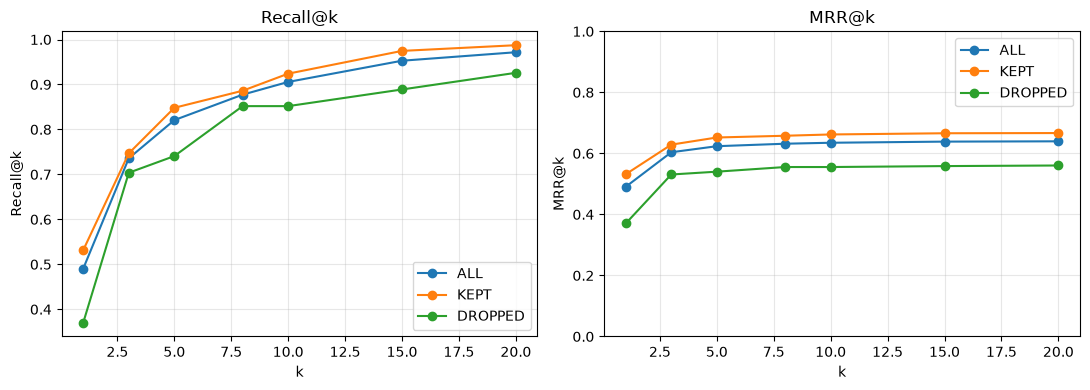

In [88]:
# --- where does the expected chunk actually sit? (MRR hides this) ---
BUCKETS = [(1, 1, 'rank 1'), (2, 2, 'rank 2'), (3, 3, 'rank 3'),
           (4, 5, 'rank 4-5'), (6, 10, 'rank 6-10'), (11, 20, 'rank 11-20'),
           (21, DEEP_SWEEP, f'rank 21-{DEEP_SWEEP}')]

print(f'{"":<14}' + ''.join(f'{lbl:>12}' for _, _, lbl in BUCKETS) + f'{"none":>8}')
for name, mask in ARMS:
    v = [r for r, m in zip(deep_ranks, mask) if m]
    if not v:
        continue
    row = ''.join(f'{sum(1 for r in v if r and lo <= r <= hi):>12}' for lo, hi, _ in BUCKETS)
    print(f'{name:<14}' + row + f'{sum(1 for r in v if r is None):>8}')

kept_v = [r for r, m in zip(deep_ranks, kept_mask) if m]
r1 = sum(1 for r in kept_v if r == 1)
print(f'\nkept set: rank-1 {r1}/{len(kept_v)} = {r1/len(kept_v):.1%} '
      '<- this is what caps MRR; k cannot move it')

try:
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    for name, mask in ARMS:
        hits = [arm_stats(ranks_at(k), mask)[2] for k in SWEEP_KS]
        mrrs = [arm_stats(ranks_at(k), mask)[3] for k in SWEEP_KS]
        ax1.plot(SWEEP_KS, hits, marker='o', label=name)
        ax2.plot(SWEEP_KS, mrrs, marker='o', label=name)
    ax1.set(xlabel='k', ylabel='Recall@k', title='Recall@k')
    ax2.set(xlabel='k', ylabel='MRR@k', title='MRR@k', ylim=(0, 1))
    for ax in (ax1, ax2):
        ax.grid(alpha=.3); ax.legend()
    plt.tight_layout(); plt.show()
except ImportError:
    print('\n(matplotlib not installed - table only)')

## Reading the results

- **Hit@k (chunk) is the number to report.** It confirms the retriever returned the exact
  labelled chunk. Nothing about it depends on text-matching heuristics.
- **Prefix-only hits** is the size of the bug this notebook fixes: those items looked like
  hits under prefix matching but the retriever never returned the source chunk - it
  returned an overlapping neighbour. If that count is large, your `chunk_overlap` is large.
- **Page-only hits** are right-page/wrong-chunk cases. A big gap between page and chunk
  Hit@k means page numbers are a weak proxy, usually because multiple documents share a
  page numbering.
- **MRR** near 1.0 means the correct chunk is usually ranked first; lower means it's
  retrieved but buried - raise `k` or improve chunking.
- **The k-sweep** now measures the same retriever you ship, and asserts as much. Pick the
  smallest k that captures most hits.
- **The failure list** is your error analysis: misses clustering on code- or math-heavy
  excerpts point at a chunking/extraction problem rather than a retrieval one.

**Caveat to state in the report.** Each question was written from its source chunk, so it
inherits that chunk's vocabulary and gives the retriever more lexical signal than a real
student query would. These numbers are therefore an upper bound on production performance.
Running the notebook twice with `PARAPHRASE = False` and `True` turns that caveat into a
measurement: the drop is your leakage estimate.